# Assignment 1
# Python Coding Exercises


In [1]:
# ==== COMMON IMPORTS ====
import math
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: for chi-square and mutual information (later exercise)
try:
    from sklearn.feature_selection import chi2, mutual_info_classif
    from sklearn.preprocessing import LabelEncoder
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

In [2]:
def max_in_list(nums):
    if not nums:
        return None
    m = nums[0]
    for x in nums[1:]:
        if x > m:
            m = x
    return m

def concat_lists(a, b):
    return a + b

def reverse_list(lst):
    return lst[::-1]

def swap_first_last(lst):
    if len(lst) < 2:
        return lst
    lst = lst[:]
    lst[0], lst[-1] = lst[-1], lst[0]
    return lst

def is_substring_in_list(target_substring, string_list):
    return any(target_substring in s for s in string_list)

# Demo
nums = [3, 10, 1, 7]
print("max:", max_in_list(nums))
print("concat:", concat_lists([1, 2], [3, 4]))
print("reverse:", reverse_list(nums))
print("swap:", swap_first_last(nums))
print("substring 'cat'?:", is_substring_in_list("cat", ["dog", "scatter", "mouse"]))

max: 10
concat: [1, 2, 3, 4]
reverse: [7, 1, 10, 3]
swap: [7, 10, 1, 3]
substring 'cat'?: True


## 2) Delete element from list at a given index

In [3]:
def delete_by_index(lst, index):
    if index < 0 or index >= len(lst):
        raise IndexError("Index out of range")
    return lst[:index] + lst[index+1:]

delete_by_index([10, 20, 30, 40], 2)

[10, 20, 40]

## 3) Check if a number is even

In [4]:
def is_even(n):
    return n % 2 == 0

for n in [2, 5, 0, -4]:
    print(n, "even?", is_even(n))

2 even? True
5 even? False
0 even? True
-4 even? True


## 4) Factorial of a number

In [5]:
def factorial(n):
    if n < 0:
        raise ValueError("Negative factorial not allowed")
    if n in (0, 1):
        return 1
    out = 1
    for k in range(2, n+1):
        out *= k
    return out

factorial(5)

120

## 5) Dictionary – print sorted by keys

In [6]:
def sorted_dict_items(d):
    return sorted(d.items(), key=lambda kv: kv[0])

d = {"banana": 3, "apple": 5, "orange": 2}
sorted_dict_items(d)

[('apple', 5), ('banana', 3), ('orange', 2)]

## 6) Lambda to return log(x) for x>0 else 'Invalid'

In [7]:
log_or_invalid = lambda x: math.log(x) if x > 0 else "Invalid"

for v in [10, 0, -3, 1]:
    print(v, "->", log_or_invalid(v))

10 -> 2.302585092994046
0 -> Invalid
-3 -> Invalid
1 -> 0.0


## 7) Add elements of two matrices

In [8]:
def add_matrices(A, B):
    if len(A) != len(B):
        raise ValueError("Matrix size mismatch")
    out = []
    for r1, r2 in zip(A, B):
        out.append([x + y for x, y in zip(r1, r2)])
    return out

add_matrices([[1, 2], [3, 4]], [[10, 20], [30, 40]])

[[11, 22], [33, 44]]

## 8) Pandas DataFrame operations


In [9]:
df = pd.DataFrame({
    "A": list(range(10, 22)),
    "B": [2*x for x in range(12)],
    "C": list("abcdefghijkl"),
})
df["D"] = df["A"] + df["B"]

# Add new row
df = pd.concat([df, pd.DataFrame([{"A": 999, "B": 888, "C": "z", "D": 999+888}])], ignore_index=True)

# Iterate first 3 rows
for idx, row in df.head(3).iterrows():
    print(idx, row.to_dict())

# Column names
print("Columns:", df.columns.tolist())

# Filter rows
df_filt = df[df["A"] <= 25]

# Excel export/import
df.to_excel("df_example.xlsx", index=False)
df_back = pd.read_excel("df_example.xlsx")

# Replace NaN in B
df_nan = df.copy()
df_nan.loc[0, "B"] = np.nan
df_nan["B"] = df_nan["B"].fillna(0)

# Set specific cell
df.at[0, "C"] = "CHANGED"

# Split 70/30
train_size = int(0.7 * len(df))
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

# Rename column
df2 = df.rename(columns={"D": "D_sum"})

df.tail(3)

0 {'A': 10, 'B': 0, 'C': 'a', 'D': 10}
1 {'A': 11, 'B': 2, 'C': 'b', 'D': 13}
2 {'A': 12, 'B': 4, 'C': 'c', 'D': 16}
Columns: ['A', 'B', 'C', 'D']


ModuleNotFoundError: No module named 'openpyxl'

## 9) Remove duplicates while preserving order

In [10]:
def remove_duplicates_preserve_order(lst):
    seen = set()
    out = []
    for x in lst:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

remove_duplicates_preserve_order([1, 2, 2, 3, 1, 4, 3])

[1, 2, 3, 4]

## 10) Character frequency in a string

In [11]:
def char_counts(s):
    for ch, c in Counter(s).items():
        print(f"{ch},{c}")

char_counts("abcdefgabc")

a,2
b,2
c,2
d,1
e,1
f,1
g,1


## 11) Check symmetrical and palindrome strings

In [12]:
def is_symmetrical(s):
    mid = len(s)//2
    if len(s) % 2 == 0:
        return s[:mid] == s[mid:]
    return s[:mid] == s[mid+1:]

def is_palindrome(s):
    return s == s[::-1]

for s in ["malayalam", "byebye", "abcba", "abc"]:
    print(s, "symmetrical:", is_symmetrical(s), "palindrome:", is_palindrome(s))

malayalam symmetrical: False palindrome: True
byebye symmetrical: True palindrome: False
abcba symmetrical: False palindrome: True
abc symmetrical: False palindrome: False


## 12) n-th Fibonacci term (recursive)

In [13]:
def fib_recursive(n):
    if n <= 0:
        raise ValueError("n must be positive")
    if n in (1, 2):
        return 1
    return fib_recursive(n-1) + fib_recursive(n-2)

[fib_recursive(i) for i in range(1, 8)]

[1, 1, 2, 3, 5, 8, 13]

## 13) Longest common substring between two strings

In [14]:
def longest_common_substring(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    max_len = 0
    end_pos = 0

    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                if dp[i][j] > max_len:
                    max_len = dp[i][j]
                    end_pos = i

    return s1[end_pos-max_len:end_pos]

s1 = "I love to look at the mountain when it is snowcapped"
s2 = " the mountain w"
longest_common_substring(s1, s2)

' the mountain w'

## 14) Evaluate a mathematical expression

In [15]:
def evaluate_expression(expr):
    try:
        return eval(expr, {"__builtins__": {}}, {})
    except Exception as e:
        return f"Error: {e}"

evaluate_expression("35 + 3 * 2")

41

## 15) Loan data – statistics & probability


Mean age: 31.51016316713987
Variance age: 140.2707459411694
Corr(Age, Time_at_address): 0.21734150131364385
P(reject | unemploye): 0.8666666666666667
Job_status
private_s    265
governmen     82
self_empl     37
unemploye     31
retired        8
student        5
military       1
Name: count, dtype: int64


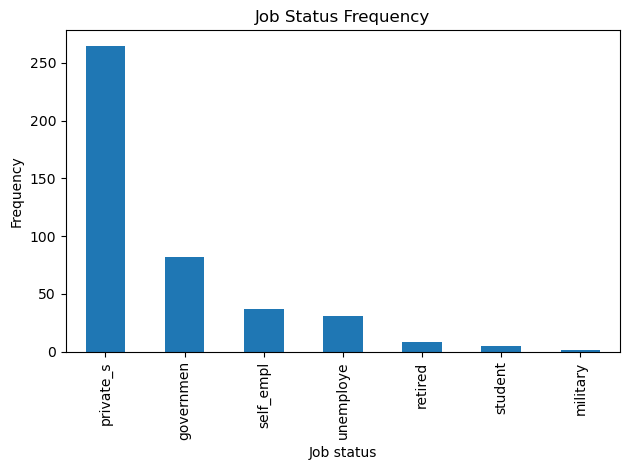

In [16]:
loan_df = pd.read_excel("loan.xlsx")

# Mean & variance of Age
print("Mean age:", loan_df["Age"].mean())
print("Variance age:", loan_df["Age"].var())

# Correlation between Age and Time_at_address
print("Corr(Age, Time_at_address):", loan_df["Age"].corr(loan_df["Time_at_address"]))

# P(Decision = reject | Occupation = unemploye) -- adjust label if needed
subset = loan_df[loan_df["Occupation"] == "unemploye"]
if len(subset) > 0:
    print("P(reject | unemploye):", (subset["Decision"] == "reject").mean())
else:
    print("No rows where Occupation == 'unemploye'")

# Job_status frequency plot
job_counts = loan_df["Job_status"].value_counts()
print(job_counts)

job_counts.plot(kind="bar")
plt.xlabel("Job status")
plt.ylabel("Frequency")
plt.title("Job Status Frequency")
plt.tight_layout()
plt.show()

## 16) Relevance between categorical inputs and Decision


In [17]:
if SKLEARN_AVAILABLE:
    cat_cols = [c for c in loan_df.columns if loan_df[c].dtype == "object" and c != "Decision"]
    le_target = LabelEncoder()
    y = le_target.fit_transform(loan_df["Decision"])

    results = []
    for col in cat_cols:
        le_feat = LabelEncoder()
        Xcol = le_feat.fit_transform(loan_df[col].astype(str)).reshape(-1, 1)
        chi_val, p_val = chi2(Xcol, y)
        mi = mutual_info_classif(Xcol, y, discrete_features=True)[0]
        results.append((col, chi_val[0], p_val[0], mi))

    results.sort(key=lambda x: x[3], reverse=True)
    print("Feature, chi2, p-value, mutual_info")
    for feature, chi_val, p_val, mi_val in results:
        print(f"{feature:15s} chi2={chi_val:.3f}, p={p_val:.3g}, MI={mi_val:.3f}")
else:
    print("scikit-learn not available in this environment.")

Feature, chi2, p-value, mutual_info
Occupation      chi2=0.347, p=0.556, MI=0.067
Job_status      chi2=18.732, p=1.5e-05, MI=0.033
Res_status      chi2=6.424, p=0.0113, MI=0.010
Telephone       chi2=6.424, p=0.0113, MI=0.010
Acc_ref         chi2=4.502, p=0.0339, MI=0.006
Liab_ref        chi2=1.094, p=0.296, MI=0.002
Sex             chi2=0.381, p=0.537, MI=0.001


## 17) Class `Lunch` with `menu_price` method

In [18]:
class Lunch:
    def __init__(self, menu: str):
        self.menu = menu

    def menu_price(self):
        if self.menu == "menu 1":
            print("Price 12.00")
        elif self.menu == "menu 2":
            print("Price 13.40")
        else:
            print("Error in menu")


Paul = Lunch("menu 1")
Paul.menu_price()

Price 12.00
